In [1]:
import time
notebook_start = time.perf_counter()
%pip install -e /home/darshan/A6/PCSAFT_cDFT/thermoift

import thermoift.semi_emperical_correlations as SEC
import thermoift.PLOT_SETTINGS as ps
import numpy as np, matplotlib.pyplot as plt
import pandas as pd

Obtaining file:///home/darshan/A6/PCSAFT_cDFT/thermoift
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for thermoift (pyproject.toml) ... done
  Created wheel for thermoift: filename=thermoift-0.2.0-0.editable-py3-none-any.whl size=1730 sha256=70b03cf1c1b9fb204c2c9a4f1965b68b430b76dc590986deed977568052c3031
  Stored in directory: /tmp/pip-ephem-wheel-cache-dv1no00c/wheels/fd/2f/c4/54a2ee5cd16a9bf5b183bbe5c28d1b3ba4926fb0261a13e1e4
Successfully built thermoift
  Attempting uninstall: thermoift
    Found existing installation: thermoift 0.2.0
    Uninstalling thermoift-0.2.0:
      Successfully uninstalled thermoift-0.2.0
Note: you may need to restart the kernel to use updated packages.


In [2]:
model = SEC.semi_emperical_correlations()
name = "carbon dioxide"
T_vals = np.arange(220, 309, 1)

rows = []
for T_K in T_vals:
    gamma0, rhoL0, rhoV0, Tc, Pc, Psat = model._pure_component_cDFT(name, T_K)
    if np.isnan(gamma0):
        continue
    rows.append((T_K, gamma0, rhoL0, rhoV0, Tc, Pc, Psat))

df = pd.DataFrame(rows, columns=['T_K', 'gamma', 'rhoL', 'rhoV', 'Tc', 'Pc', 'Psat'])
path = 'pure_component_results.csv'
[df.to_csv(path, index=False), print(f"Saved {len(df)} rows to {path}")]

/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:160: UserWarning: cDFT solve failed for pure component 'carbon dioxide (From semi_emperical_correlations)' at T=298 K: `DFT` did not converge within the maximum number of iterations.
  warnings.warn(
/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:160: UserWarning: cDFT solve failed for pure component 'carbon dioxide (From semi_emperical_correlations)' at T=300 K: `DFT` did not converge within the maximum number of iterations.
  warnings.warn(


Saved 79 rows to pure_component_results.csv


/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:160: UserWarning: cDFT solve failed for pure component 'carbon dioxide (From semi_emperical_correlations)' at T=301 K: `DFT` did not converge within the maximum number of iterations.
  warnings.warn(
/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:160: UserWarning: cDFT solve failed for pure component 'carbon dioxide (From semi_emperical_correlations)' at T=302 K: `DFT` did not converge within the maximum number of iterations.
  warnings.warn(
/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:160: UserWarning: cDFT solve failed for pure component 'carbon dioxide (From semi_emperical_correlations)' at T=303 K: `DFT` did not converge within the maximum number of iterations.
  warnings.warn(
/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:160: UserWarning: cDFT solve failed for pure component 'carbon d

[None, None]

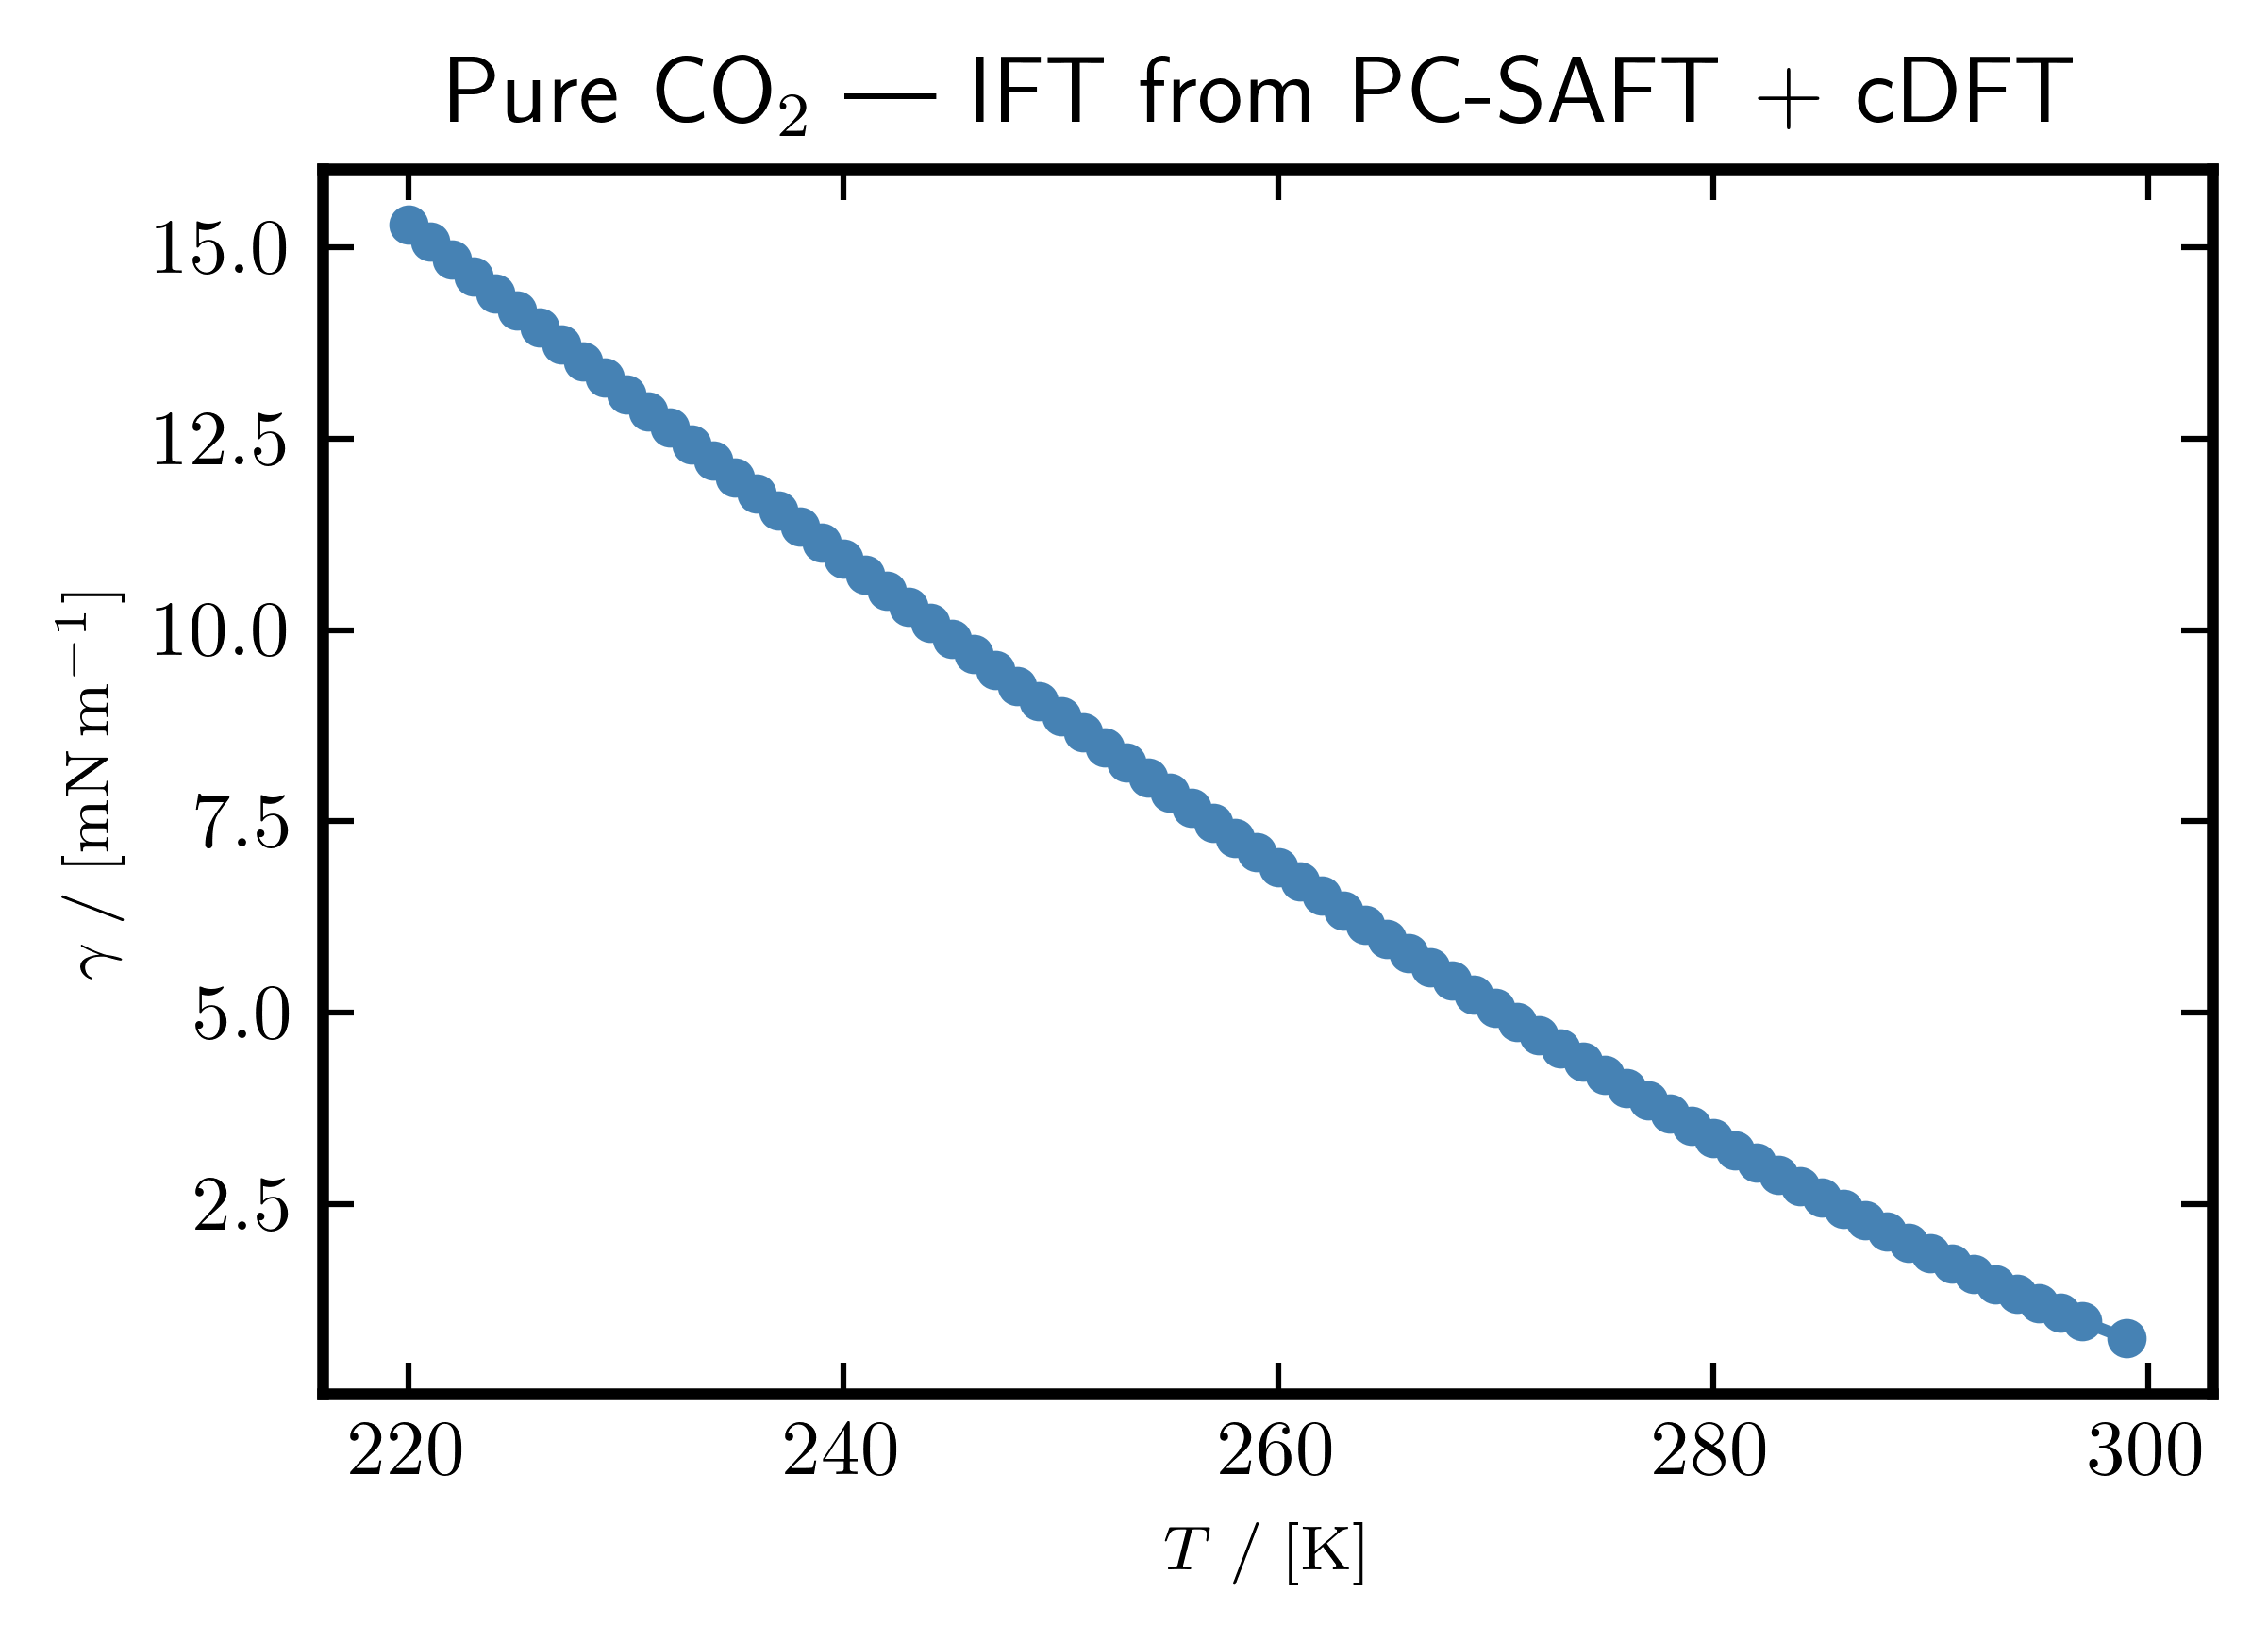

In [3]:
fig, ax = ps.plot_init()
ax.plot(df['T_K'], df['gamma'], "o-", markersize=4, color="steelblue")
ax.set_xlabel(r"$T \; / \; [\mathrm{K}]$")
ax.set_ylabel(r"$\gamma \; / \; [\mathrm{mN \, m^{-1}}]$")
ax.set_title(r"Pure CO$_2$ — IFT from PC-SAFT + cDFT")
plt.tight_layout()
plt.show()

In [4]:
TC = 309.1473760575555

def surface_tension(T, Tc):
    """
    Surface tension correlation (Equation 3).

    sigma = 82.395 * (1 - T/Tc)^1.351

    Parameters
    ----------
    T  : float or array-like
        Temperature [K]
    Tc : float
        Critical temperature [K]

    Returns
    -------
    sigma : float or ndarray
        Surface tension [mN/m]
    """
    T  = np.asarray(T,  dtype=float)
    Tc = float(Tc)

    if np.any(T < 0):
        raise ValueError("T must be non-negative [K]")
    if np.any(T >= Tc):
        raise ValueError("T must be below critical temperature Tc")

    sigma0 = 82.395   # mN/m  (= 26.19^1.351)
    n0     = 1.351

    return sigma0 * (1.0 - T / Tc) ** n0


T_range = np.linspace(220, TC, 100, endpoint=False)  # excludes TC itself
sigma   = surface_tension(T_range, TC)

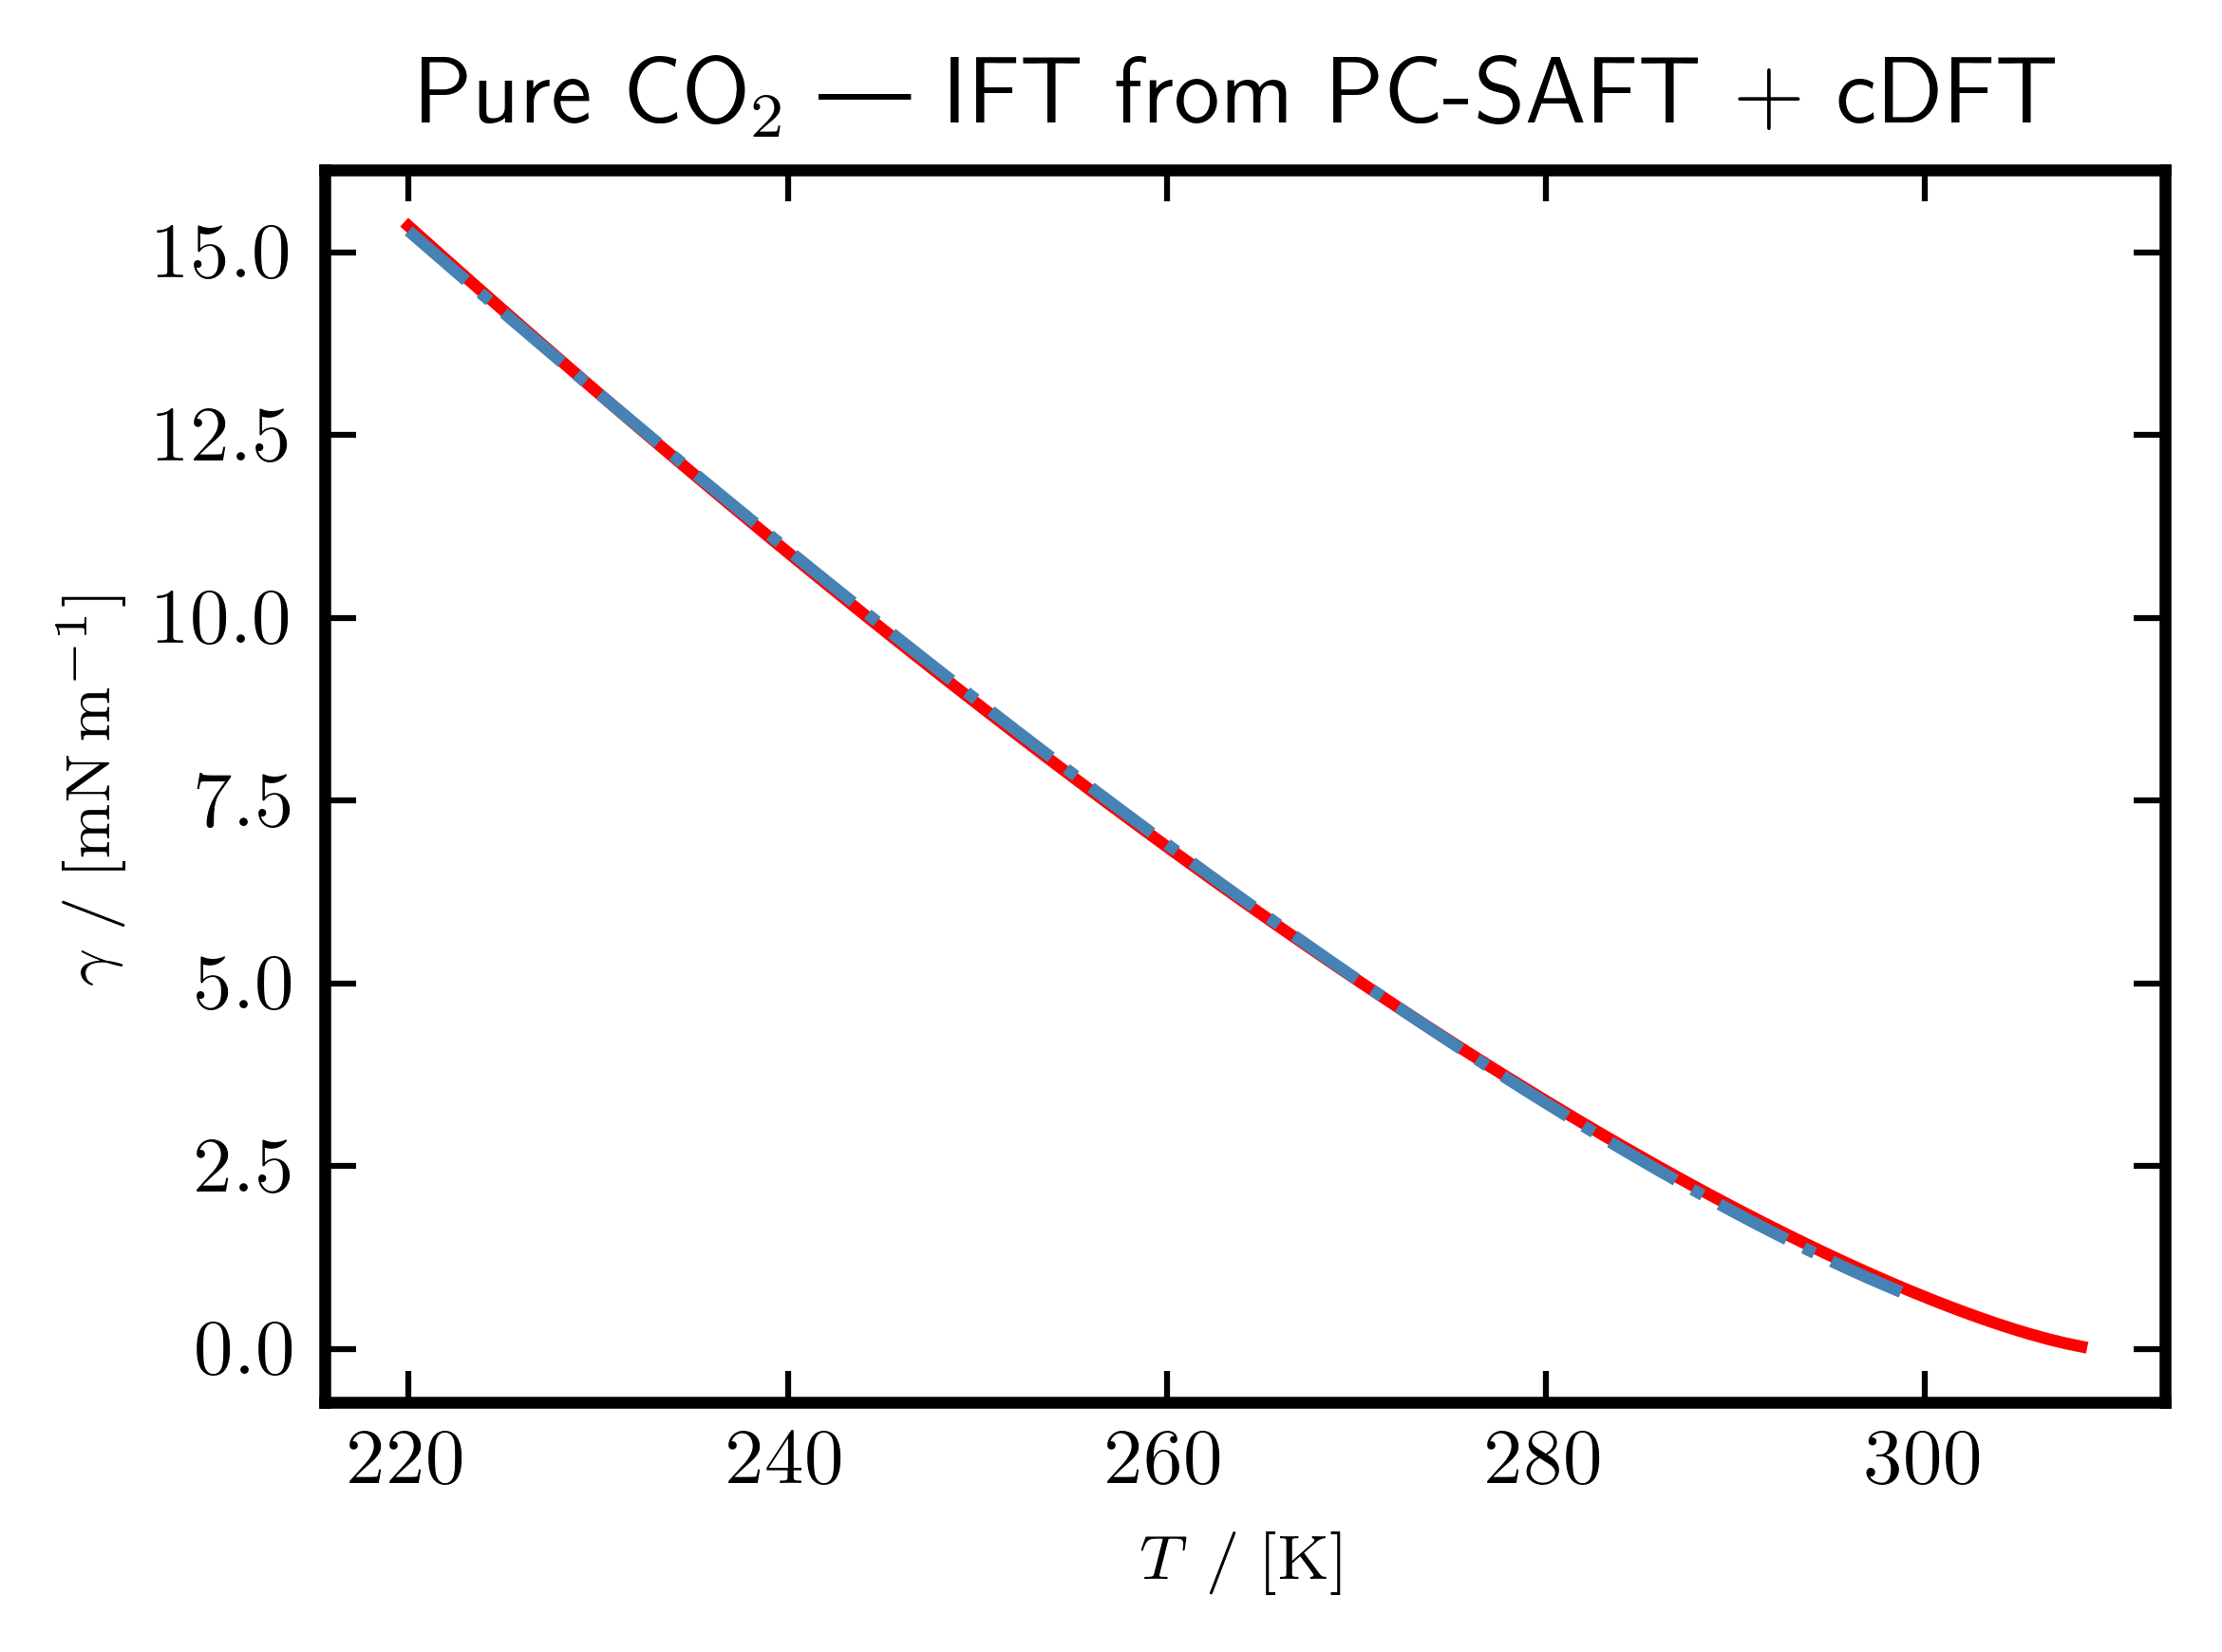

In [5]:
fig, ax = ps.plot_init()
ax.plot(T_range, sigma, "-", markersize=4, color="red")
ax.plot(df['T_K'], df['gamma'], "-.", markersize=4, color="steelblue")
ax.set_xlabel(r"$T \; / \; [\mathrm{K}]$")
ax.set_ylabel(r"$\gamma \; / \; [\mathrm{mN \, m^{-1}}]$")
ax.set_title(r"Pure CO$_2$ — IFT from PC-SAFT + cDFT")
plt.tight_layout()
plt.show()

In [6]:
# Compute pure surface tension using InterfacialTension from Interfacethermopy
import sys
sys.path.insert(0, '/home/darshan/A6/PCSAFT_cDFT/Interfacethermopy/src')
from Interfacethermopy.Interfacethermopy import InterfacialTension

ift = InterfacialTension('Mulero_2012.json')

rp_path = "/home/darshan/Software/REFPROP/REFPROP-cmake/build"
ift.ctREFPROP_init(rp_path)
fluid_name = "CO2"
T_range_pure = np.arange(220, 300, 1)

gamma_pure = []
for T in T_range_pure:
    gamma_T, T_used = ift.compute_gamma_pure(T, fluid_name, key='Parachor')
    gamma_pure.append(gamma_T)

gamma_pure = np.array(gamma_pure)

REFPROP version = 10.0
GERG-2008 model = Disabled


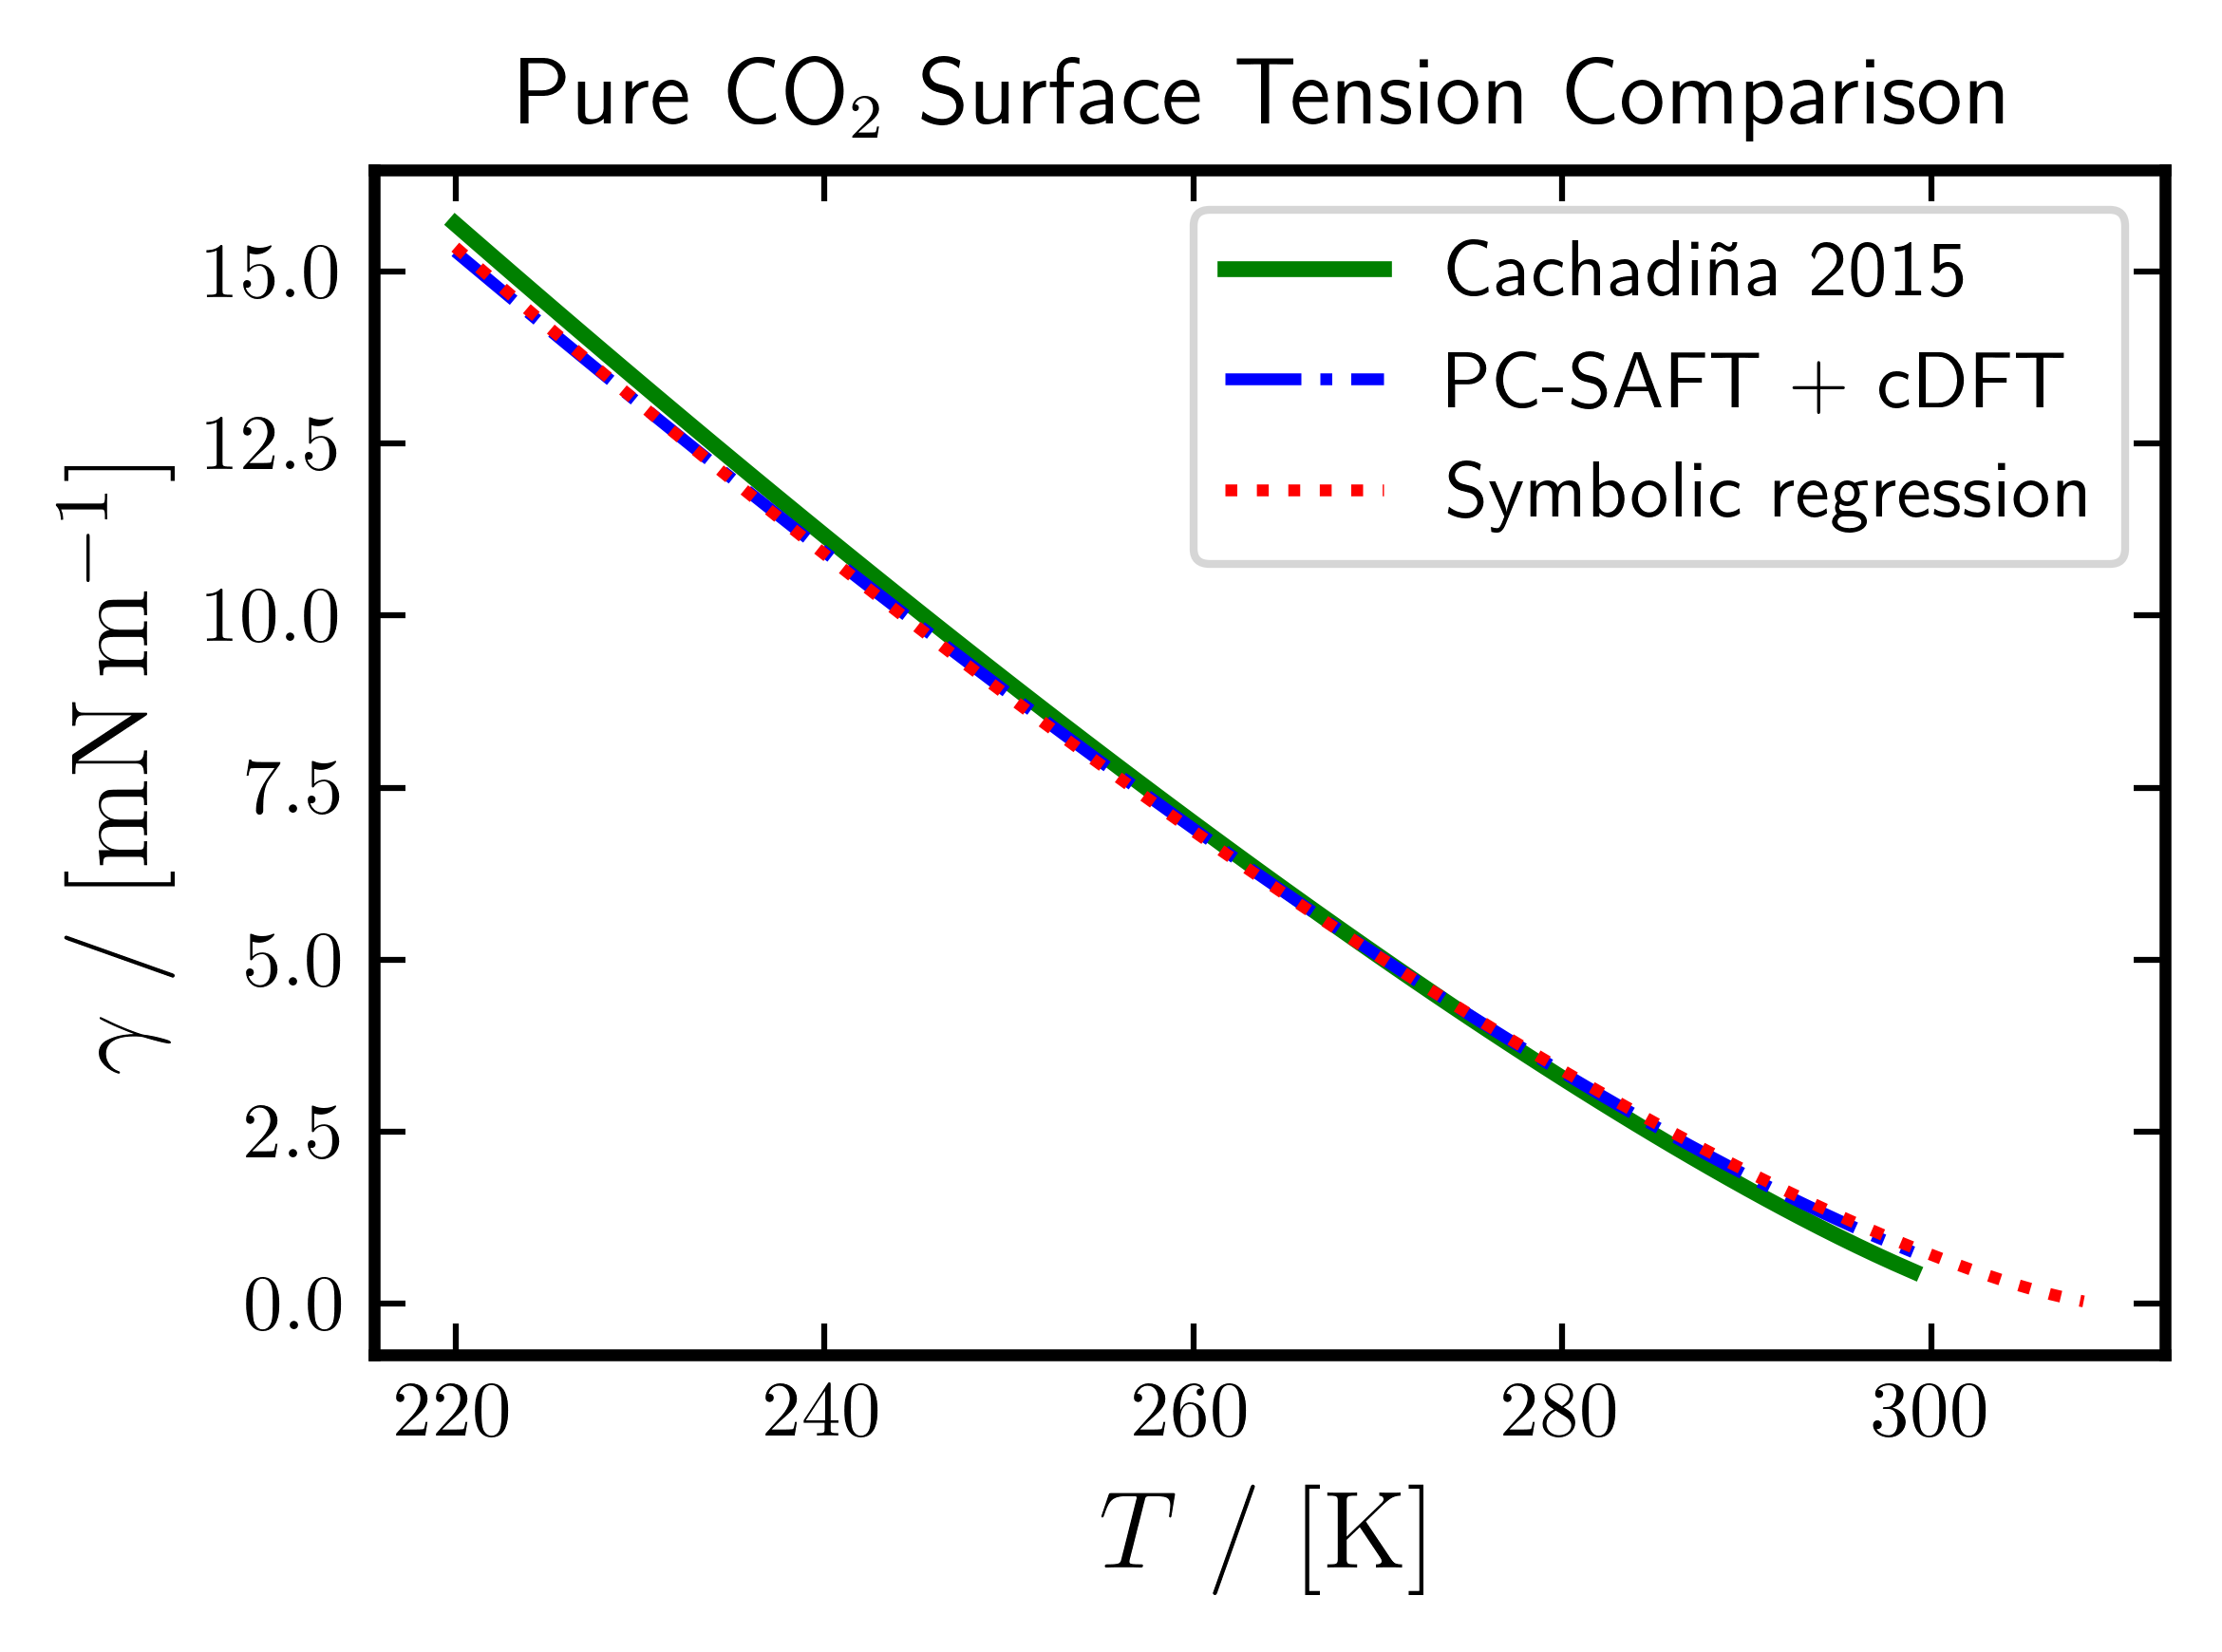

In [12]:
# Plot comparison
fig, ax = ps.plot_init()
ax.plot(T_range_pure, gamma_pure, "-", lw=2, color="green", label="Cachadiña 2015")
ax.plot(df['T_K'], df['gamma'], "-.", markersize=4, color="blue", label="PC-SAFT + cDFT")
ax.plot(T_range, sigma, ":", markersize=4, color="red", label="Symbolic regression")
ax.set_xlabel(r"$T \; / \; [\mathrm{K}]$", fontsize=ps.label_fontsize)
ax.set_ylabel(r"$\gamma \; / \; [\mathrm{mN \, m^{-1}}]$", fontsize=ps.label_fontsize)
ax.set_title(r"Pure CO$_2$ Surface Tension Comparison", fontsize=ps.title_fontsize)
ax.legend()
plt.tight_layout()
plt.show()